In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
df = pd.read_csv("Ventas.csv")
df

,Fecha,DíaDeLaSemana,Promociones,Festivo,Ventas
0,2022-01-01,6,0,0,4033
1,2022-01-02,7,0,1,4012
2,2022-01-03,1,0,0,1608
3,2022-01-04,2,1,0,2046
4,2022-01-05,3,0,0,2484
...,...,...,...,...,...
360,2022-12-27,2,1,0,2189
361,2022-12-28,3,0,0,2548
362,2022-12-29,4,0,0,3018
363,2022-12-30,5,0,0,3591


In [7]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df

,Fecha,DíaDeLaSemana,Promociones,Festivo,Ventas
0,2022-01-01,6,0,0,4033
1,2022-01-02,7,0,1,4012
2,2022-01-03,1,0,0,1608
3,2022-01-04,2,1,0,2046
4,2022-01-05,3,0,0,2484
...,...,...,...,...,...
360,2022-12-27,2,1,0,2189
361,2022-12-28,3,0,0,2548
362,2022-12-29,4,0,0,3018
363,2022-12-30,5,0,0,3591


In [15]:
escala = MinMaxScaler(feature_range=(0,1))
col_escalar = df.drop(["Ventas", "Fecha"], axis=1).columns
normado = escala.fit_transform(df[col_escalar])
df_normado = pd.DataFrame (data=normado, columns=col_escalar)
df_normado["Ventas"] = df["Ventas"]
df_normado["Fecha"] = df["Fecha"]
df_normado

,DíaDeLaSemana,Promociones,Festivo,Ventas,Fecha
0,0.833333,0.0,0.0,4033,2022-01-01
1,1.000000,0.0,1.0,4012,2022-01-02
2,0.000000,0.0,0.0,1608,2022-01-03
3,0.166667,1.0,0.0,2046,2022-01-04
4,0.333333,0.0,0.0,2484,2022-01-05
...,...,...,...,...,...
360,0.166667,1.0,0.0,2189,2022-12-27
361,0.333333,0.0,0.0,2548,2022-12-28
362,0.500000,0.0,0.0,3018,2022-12-29
363,0.666667,0.0,0.0,3591,2022-12-30


In [20]:
X = df_normado.drop(["Ventas", "Fecha"], axis=1)
y = df_normado["Ventas"]
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(X, y, train_size=0.85)

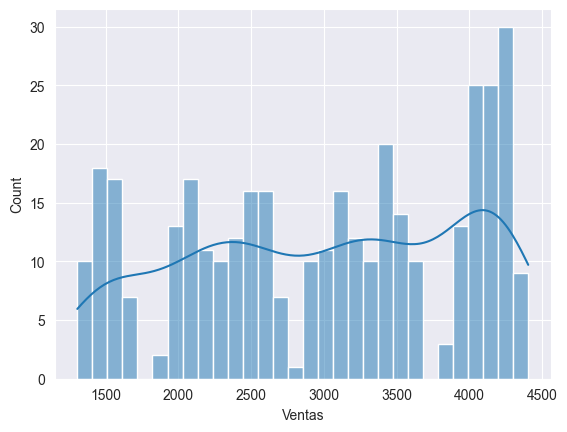

In [24]:
sns.histplot(df["Ventas"], bins= 30, kde=True);

<Axes: xlabel='DíaDeLaSemana', ylabel='Ventas'>

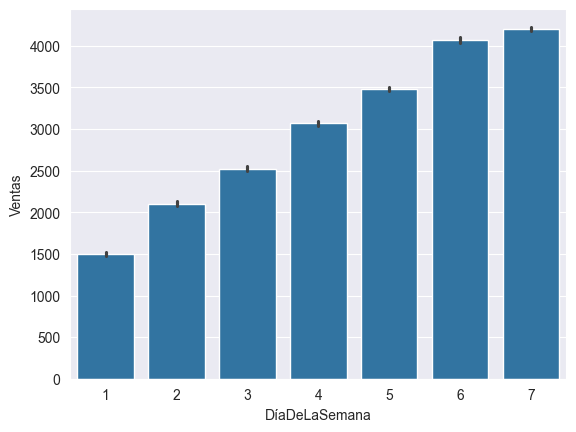

In [27]:
sns.barplot(data=df, x= "DíaDeLaSemana", y = "Ventas")

In [44]:
modelo = LinearRegression()
resultado = modelo.fit(X_entrena,y_entrena)
linea_predictiva = resultado.predict(X_prueba)

In [46]:
resultado.score(X_prueba,y_prueba)

0.991509714754292

''

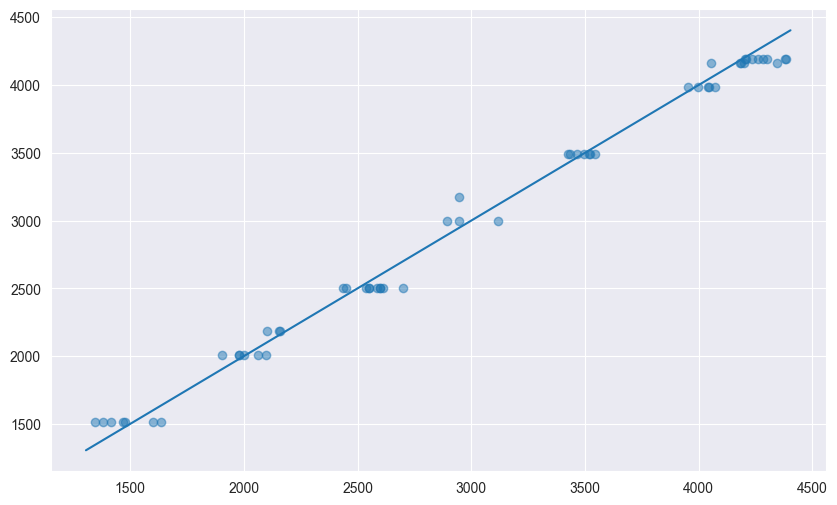

In [50]:
plt.figure(figsize=(10,6))
plt.scatter(y_prueba, linea_predictiva, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt
;

In [52]:
df_test = pd.DataFrame({"Real":y_prueba, "Prediccion":linea_predictiva})
df_test = df_test.sort_index()
df_test

,Real,Prediccion
6,3545,3492.687044
11,2535,2503.719856
25,2610,2503.719856
31,1998,2009.236262
42,3952,3987.170638
44,1381,1514.752668
46,2435,2503.719856
51,1470,1514.752668
53,2600,2503.719856
76,3494,3492.687044


''

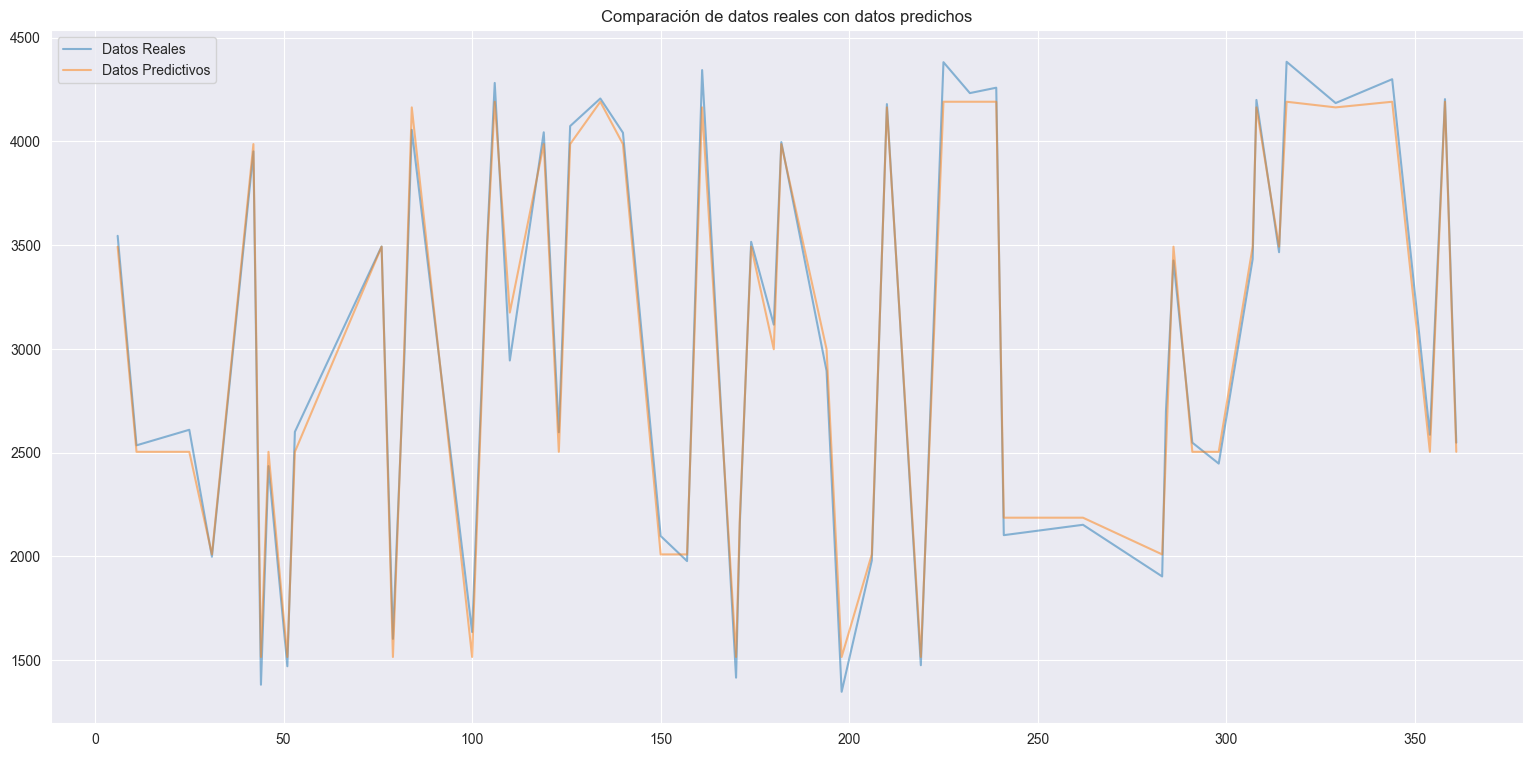

In [60]:
plt.figure(figsize=(19,9))
plt.plot(df_test["Real"], label="Datos Reales", alpha=0.5)
plt.plot(df_test["Prediccion"], label="Datos Predictivos", alpha=0.5)
plt.legend()
plt.title("Comparación de datos reales con datos predichos")
;